In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/in-context-learning/src


/content/drive/MyDrive/in-context-learning/src


In [3]:
!pip install munch
# should change import imp to import importlib

In [4]:
from collections import OrderedDict
import re
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names

%matplotlib inline
%load_ext autoreload
%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"

In [5]:
%cd /content/drive/MyDrive/in-context-learning/models/polynomial_regression/baseline/
#%cd /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/
import torch

#convert checkpoint to .pt file
checkpoint_path = "checkpoint_3000000.zip"
output_path = "model_0.pt"
out_put_dir="./"

ckpt = torch.load(checkpoint_path, map_location="cpu")

state_dict = ckpt["model_state_dict"]

torch.save(state_dict, output_path)

print("Exported state.pt successfully!")

_ = get_run_metrics(out_put_dir,step=0) #rerun the evaluation

%cd /content/drive/MyDrive/in-context-learning/src

/content/drive/MyDrive/in-context-learning/models/polynomial_regression/baseline
Exported state.pt successfully!
Munch({'model': Munch({'family': 'gpt2', 'vocab_size': 1, 'glu_type': 'None', 'n_dims': 1, 'n_embd': 128, 'n_head': 4, 'n_layer': 6, 'n_positions': 81}), 'out_dir': '../models/polynomial_regression/baseline', 'test_run': True, 'training': Munch({'batch_size': 64, 'curriculum': Munch({'degree': Munch({'end': 11, 'inc': 2, 'interval': 2000, 'start': 1}), 'points': Munch({'end': 81, 'inc': 2, 'interval': 2000, 'start': 5})}), 'data': 'uniform', 'keep_every_steps': 100000, 'learning_rate': 0.0001, 'num_tasks': None, 'num_training_examples': None, 'resume_id': None, 'save_every_steps': 1000, 'task': 'polynomial_regression', 'task_kwargs': Munch({}), 'train_steps': 3002000}), 'wandb': Munch({'entity': 'quzhaorui22-university-of-chinese-of-academy-of-sciences', 'log_every_steps': 100, 'name': 'polynomial_regression_toy', 'notes': '', 'project': 'in-context-training'})})


  0%|          | 0/8 [00:00<?, ?it/s]

{}
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: 

 12%|█▎        | 1/8 [01:39<11:33, 99.09s/it]

{'max_degree': 12, 'noise': False}
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_std: 0
in evaluate poly_family: chebyshev
in evaluate degree: 12
in evaluate noise: False
in evaluate noise_

...

{'noise': True, 'noise_std': 0.1}
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: chebyshev
in evaluate degree: 11
in evaluate noise: True
in evaluate 

 88%|████████▊ | 7/8 [11:11<01:34, 94.45s/it]

{'poly_family': 'monomial', 'noise': True, 'noise_std': 0.1}
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise: True
in evaluate noise_std: 0.1
in evaluate poly_family: monomial
in evaluate degree: 11
in evaluate noise:

100%|██████████| 8/8 [12:46<00:00, 95.80s/it]

/content/drive/MyDrive/in-context-learning/src


In [6]:
%cd /content/drive/MyDrive/src
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

[Errno 2] No such file or directory: '/content/drive/MyDrive/src'
/content/drive/MyDrive/in-context-learning/src
moe
baseline


,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
1,baseline,polynomial_regression,Transformer-small,,-1,-1,1,6,4,polynomial_regression/baseline
0,moe,polynomial_regression,polynomial_regression_toy,,-1,-1,1,6,4,polynomial_regression/moe


In [7]:

task = "polynomial_regression"

run_id = "baseline"
#run_id = "moe"


run_path = os.path.join(run_dir, task, run_id)

# Plot pre-computed metrics

polynomial_regression/baseline baseline
Munch({'model': Munch({'family': 'gpt2', 'vocab_size': 1, 'glu_type': 'None', 'n_dims': 1, 'n_embd': 128, 'n_head': 4, 'n_layer': 6, 'n_positions': 81}), 'out_dir': '../models/polynomial_regression/baseline', 'test_run': True, 'training': Munch({'batch_size': 64, 'curriculum': Munch({'degree': Munch({'end': 11, 'inc': 2, 'interval': 2000, 'start': 1}), 'points': Munch({'end': 81, 'inc': 2, 'interval': 2000, 'start': 5})}), 'data': 'uniform', 'keep_every_steps': 100000, 'learning_rate': 0.0001, 'num_tasks': None, 'num_training_examples': None, 'resume_id': None, 'save_every_steps': 1000, 'task': 'polynomial_regression', 'task_kwargs': Munch({}), 'train_steps': 3002000}), 'wandb': Munch({'entity': 'quzhaorui22-university-of-chinese-of-academy-of-sciences', 'log_every_steps': 100, 'name': 'polynomial_regression_toy', 'notes': '', 'project': 'in-context-training'})})


100%|██████████| 8/8 [00:00<00:00, 101372.91it/s]

gpt2_embd=128_layer=6_head=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_embd=128_layer=6_head=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_embd=128_layer=6_head=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_embd=128_layer=6_head=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_embd=128_layer=6_head=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_embd=128_layer=6_head=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_embd=128_layer=6_head=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_embd=128_layer=6_head=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4


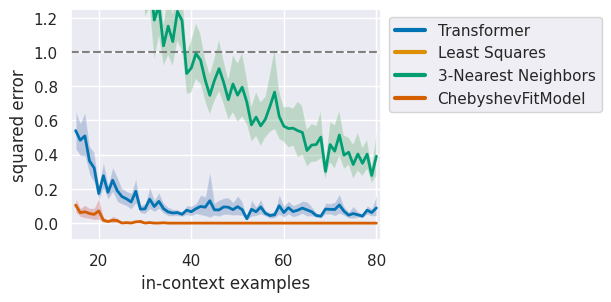

In [8]:
def valid_row(r):
    return r.task == task and r.run_id == run_id

metrics = collect_results(run_dir, df, valid_row=valid_row)
_, conf = get_model_from_run(run_path, only_conf=True)
n_dims = conf.model.n_dims

models = relevant_model_names[task]
print(metrics)
basic_plot(metrics["standard"], models=models)
plt.show()
#baseline model may be wrong(need further investigation)

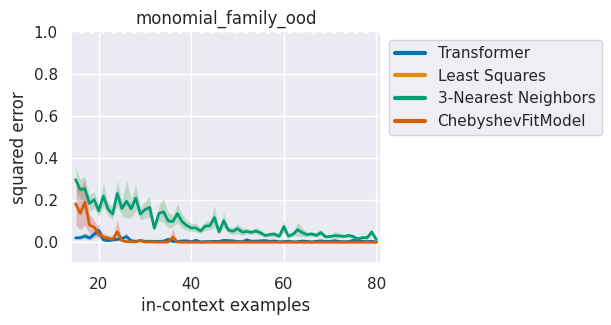

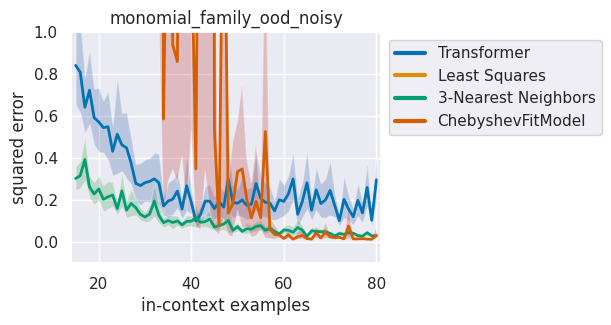

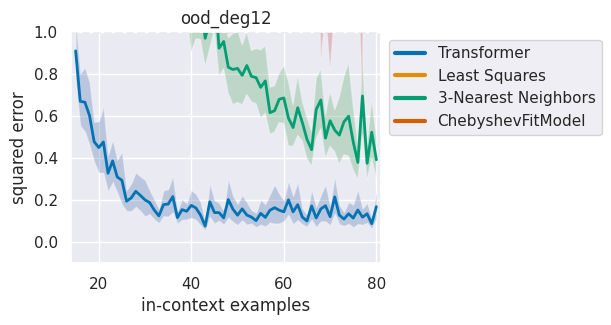

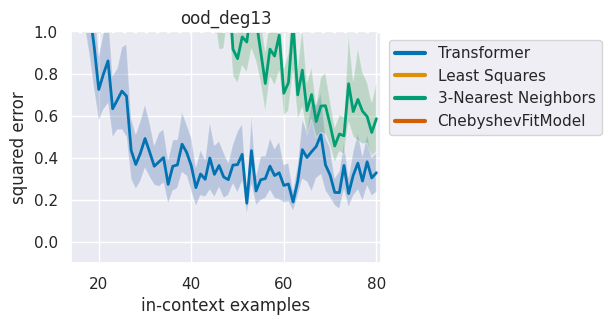

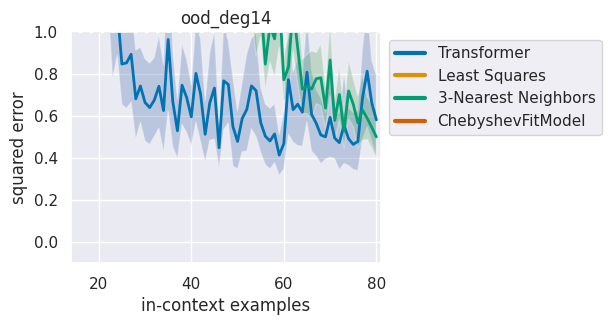

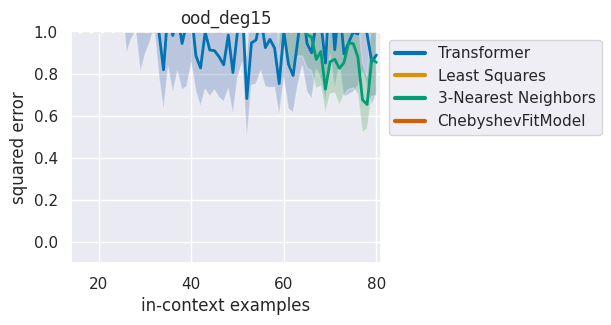

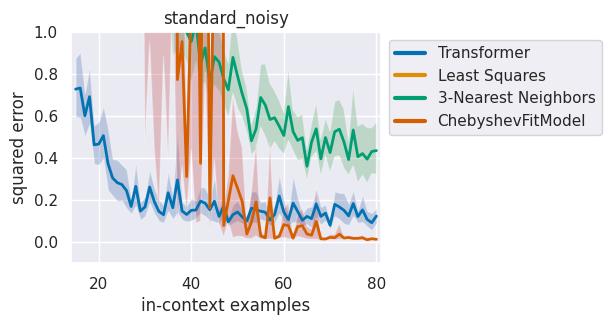

In [9]:
# plot any OOD metrics
for name, metric in metrics.items():
    if name == "standard": continue

    if "scale" in name:
        scale = float(name.split("=")[-1])**2
    else:
        scale = 1.0

    trivial = 1.0 if "noisy" not in name else (1+1/n_dims)
    fig, ax = basic_plot(metric, models=models, trivial=trivial * scale)
    ax.set_title(name)

    if "ortho" in name:
        ax.set_xlim(-1, n_dims - 1)
    ax.set_ylim(-0.1* scale, 1 * scale)

    plt.show()

In [ ]:
#used for training
!pip install pyyaml==6.0.1
!pip install quinine --no-deps
!pip install Cerberus==1.3.2


In [ ]:
!pip install cytoolz
!pip install funcy
!pip install toposort

In [ ]:
!python train.py --config conf/toy.yaml